In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


In [ ]:
from google.colab import files

uploaded = files.upload()
import pandas as pd

df = pd.read_csv("heart_disease.csv")
df.head(10)

Saving heart_disease.csv to heart_disease (3).csv


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,No,Low,Medium,5.504876,Low,126.0,91.0,4.297575,10.815983,No
6,78.0,Female,121.0,175.0,High,Yes,Yes,Yes,18.042332,No,...,No,Medium,Medium,9.240911,Medium,107.0,85.0,11.582983,19.659461,No
7,38.0,Female,161.0,187.0,Low,Yes,Yes,Yes,34.736683,No,...,No,Low,Medium,7.841008,High,228.0,111.0,4.929381,17.146599,No
8,56.0,Female,135.0,291.0,Low,No,Yes,Yes,34.493112,Yes,...,Yes,High,Low,6.941403,High,317.0,103.0,5.119015,6.051129,No
9,75.0,Male,144.0,252.0,Low,Yes,Yes,No,30.142149,No,...,Yes,Low,Medium,4.002662,High,199.0,96.0,10.005698,7.604357,No


In [ ]:
# get all the column name
df.columns=df.columns.str.strip().str.lower()
print(df.columns)

Index(['age', 'gender', 'blood pressure', 'cholesterol level',
       'exercise habits', 'smoking', 'family heart disease', 'diabetes', 'bmi',
       'high blood pressure', 'low hdl cholesterol', 'high ldl cholesterol',
       'alcohol consumption', 'stress level', 'sleep hours',
       'sugar consumption', 'triglyceride level', 'fasting blood sugar',
       'crp level', 'homocysteine level', 'heart disease status'],
      dtype='object')


In [ ]:
# check missing value
df.isnull().sum()

,0
age,29
gender,19
blood pressure,19
cholesterol level,30
exercise habits,25
smoking,25
family heart disease,21
diabetes,30
bmi,22
high blood pressure,26


In [ ]:
df.shape

(10000, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   9971 non-null   float64
 1   gender                9981 non-null   object 
 2   blood pressure        9981 non-null   float64
 3   cholesterol level     9970 non-null   float64
 4   exercise habits       9975 non-null   object 
 5   smoking               9975 non-null   object 
 6   family heart disease  9979 non-null   object 
 7   diabetes              9970 non-null   object 
 8   bmi                   9978 non-null   float64
 9   high blood pressure   9974 non-null   object 
 10  low hdl cholesterol   9975 non-null   object 
 11  high ldl cholesterol  9974 non-null   object 
 12  alcohol consumption   7414 non-null   object 
 13  stress level          9978 non-null   object 
 14  sleep hours           9975 non-null   float64
 15  sugar consumption   

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print(df.isnull().sum())

age                     0
gender                  0
blood pressure          0
cholesterol level       0
exercise habits         0
smoking                 0
family heart disease    0
diabetes                0
bmi                     0
high blood pressure     0
low hdl cholesterol     0
high ldl cholesterol    0
alcohol consumption     0
stress level            0
sleep hours             0
sugar consumption       0
triglyceride level      0
fasting blood sugar     0
crp level               0
homocysteine level      0
heart disease status    0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10000 non-null  float64
 1   gender                10000 non-null  int64  
 2   blood pressure        10000 non-null  float64
 3   cholesterol level     10000 non-null  float64
 4   exercise habits       10000 non-null  int64  
 5   smoking               10000 non-null  int64  
 6   family heart disease  10000 non-null  int64  
 7   diabetes              10000 non-null  int64  
 8   bmi                   10000 non-null  float64
 9   high blood pressure   10000 non-null  int64  
 10  low hdl cholesterol   10000 non-null  int64  
 11  high ldl cholesterol  10000 non-null  int64  
 12  alcohol consumption   10000 non-null  int64  
 13  stress level          10000 non-null  int64  
 14  sleep hours           10000 non-null  float64
 15  sugar consumption   

In [ ]:
X = df.drop('heart disease status', axis=1)
y = df['heart disease status']

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)

Accuracy = 0.8065


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1613    0]
 [ 387    0]]


                Feature  Importance
14          sleep hours    0.096991
18            crp level    0.096844
19   homocysteine level    0.096143
8                   bmi    0.095203
16   triglyceride level    0.087822
3     cholesterol level    0.083972
0                   age    0.080501
17  fasting blood sugar    0.080156
2        blood pressure    0.079794
12  alcohol consumption    0.029372


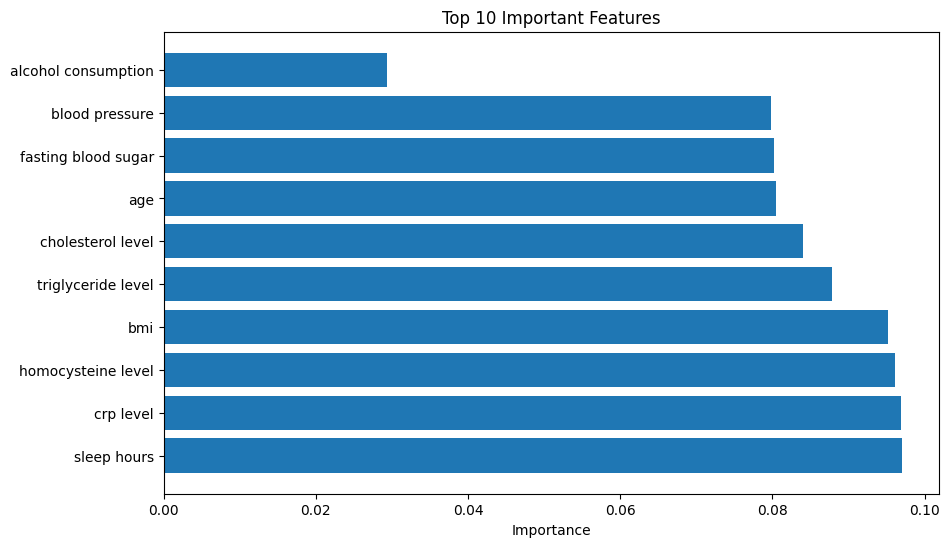

In [ ]:


importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()